<a href="https://colab.research.google.com/github/beyzoskaya/estimating-biodiversity/blob/main/BiodiversityEstimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Toy experiment: unseen country–capital knowledge in a small LLM

This notebook uses the frozen pretrained model `Qwen/Qwen2.5-0.5B-Instruct`. It performs inference only—no training or fine-tuning.

## Ecological mapping

| Ecology | Experiment |
|---|---|
| Species | One correct canonical country–capital pair |
| Observation | One generated occurrence of a correct pair |
| Sampling unit | One fresh LLM call |
| Observed richness | Number of distinct correct pairs observed |
| Unseen richness | Accessible correct pairs not yet observed |
| Sampling effort | Number of LLM calls |

The experiment has two phases:

1. **Direct exhaustive probing** over a 12-fact universe to approximate the model's accessible set.
2. **Limited free-choice sampling** to create fact-frequency counts and calculate Chao1 and Good–Turing estimates.

In [ ]:
!pip -q install -U "transformers>=4.45" accelerate pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 113.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 121.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


In [ ]:
import ast
import json
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
print("Device:", device)

Device: cuda


In [ ]:
GROUND_TRUTH = {
    "France": "Paris",
    "Japan": "Tokyo",
    "Türkiye": "Ankara",
    "Brazil": "Brasilia",
    "Canada": "Ottawa",
    "Australia": "Canberra",
    "Estonia": "Tallinn",
    "Mongolia": "Ulaanbaatar",
    "Suriname": "Paramaribo",
    "Palau": "Ngerulmud",
    "Comoros": "Moroni",
    "Micronesia": "Palikir",
}

ALIASES = {
    "brasilia": "Brasilia",
    "brasília": "Brasilia",
    "turkey": "Türkiye",
    "turkiye": "Türkiye",
    "türkiye": "Türkiye",
    "federated states of micronesia": "Micronesia",
    "micronesia": "Micronesia",
}

pd.DataFrame(
    [{"country": country, "capital": capital}
     for country, capital in GROUND_TRUTH.items()]
)

,country,capital
0,France,Paris
1,Japan,Tokyo
2,Türkiye,Ankara
3,Brazil,Brasilia
4,Canada,Ottawa
5,Australia,Canberra
6,Estonia,Tallinn
7,Mongolia,Ulaanbaatar
8,Suriname,Paramaribo
9,Palau,Ngerulmud


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
).to(device)
model.eval()
print("Loaded:", MODEL_ID)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-0.5B-Instruct


In [ ]:
def generate_one(prompt, *, do_sample, temperature=0.8, max_new_tokens=50):
    messages = [
        {
            "role": "system",
            "content": (
                "You are a factual assistant. Follow the requested output format. "
                "Do not invent countries outside the supplied list."
            ),
        },
        {"role": "user", "content": prompt},
    ]
    formatted = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(formatted, return_tensors="pt").to(device)

    kwargs = {
        **inputs,
        "max_new_tokens": max_new_tokens,
        "do_sample": do_sample,
        "pad_token_id": tokenizer.eos_token_id,
    }
    if do_sample:
        kwargs.update(temperature=temperature, top_p=0.95)

    with torch.inference_mode():
        output = model.generate(**kwargs)

    new_tokens = output[0, inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


def normalize_country(value):
    value = str(value).strip().strip('"').strip("'")
    return ALIASES.get(value.casefold(), value)


def normalize_capital(value):
    value = str(value).strip().strip('"').strip("'")
    return value[:-1] if value.endswith(".") else value


def parse_pair(text):
    match = re.search(r"\{.*?\}", text, flags=re.DOTALL)
    if match:
        candidate = match.group(0)
        for parser in (json.loads, ast.literal_eval):
            try:
                obj = parser(candidate)
                if isinstance(obj, dict):
                    country = obj.get("country")
                    capital = obj.get("capital")
                    if country is not None and capital is not None:
                        return normalize_country(country), normalize_capital(capital)
            except Exception:
                pass

    match = re.search(
        r"country\s*[:=-]\s*([^,\n;]+).*?capital\s*[:=-]\s*([^,\n;}]+)",
        text,
        flags=re.IGNORECASE | re.DOTALL,
    )
    if match:
        return (
            normalize_country(match.group(1)),
            normalize_capital(match.group(2)),
        )
    return None, None


def evaluate_pair(country, capital):
    if country not in GROUND_TRUTH or capital is None:
        return False
    return capital.casefold() == GROUND_TRUTH[country].casefold()

# Phase A: approximate accessible richness

Each country is directly queried with three prompt templates and three repetitions. A fact is marked **accessible** if the correct capital appears at least once.

This empirical target means:

> accessible under this defined family of prompts and generation settings.

It does not prove what is internally represented in the weights.

In [ ]:
DIRECT_TEMPLATES = [
    'What is the capital of {country}? Return JSON: {{"country": "{country}", "capital": "CITY"}}',
    'Complete this fact: the capital city of {country} is what? Return JSON only with keys country and capital.',
    'Name the current capital of {country}. Output exactly one JSON object with country and capital.',
]
DIRECT_REPEATS = 3
direct_rows = []

for country, gold_capital in GROUND_TRUTH.items():
    for template_id, template in enumerate(DIRECT_TEMPLATES):
        for repeat in range(DIRECT_REPEATS):
            raw = generate_one(
                template.format(country=country),
                do_sample=True,
                temperature=0.5,
                max_new_tokens=40,
            )
            _, parsed_capital = parse_pair(raw)
            is_correct = (
                parsed_capital is not None
                and parsed_capital.casefold() == gold_capital.casefold()
            )
            direct_rows.append({
                "country": country,
                "gold_capital": gold_capital,
                "template_id": template_id,
                "repeat": repeat,
                "raw_output": raw,
                "parsed_capital": parsed_capital,
                "is_correct": is_correct,
            })

direct_df = pd.DataFrame(direct_rows)
direct_df.head(10)

,country,gold_capital,template_id,repeat,raw_output,parsed_capital,is_correct
0,France,Paris,0,0,"{""country"": ""France"", ""capital"": ""Paris""}",Paris,True
1,France,Paris,0,1,"{""country"": ""France"", ""capital"": ""Paris""}",Paris,True
2,France,Paris,0,2,"{""country"": ""France"", ""capital"": ""Paris""}",Paris,True
3,France,Paris,1,0,"```json\n{\n ""country"": ""France"",\n ""capital...",Paris,True
4,France,Paris,1,1,"```json\n{\n ""country"": ""France"",\n ""capital...",Paris,True
5,France,Paris,1,2,"{\n ""country"": ""France"",\n ""capital"": ""Paris...",Paris,True
6,France,Paris,2,0,"{\n ""country"": ""France"",\n ""capital"": ""Paris...",Paris,True
7,France,Paris,2,1,"{\n ""country"": ""France"",\n ""capital"": ""Paris...",Paris,True
8,France,Paris,2,2,"{\n ""country"": ""France"",\n ""capital"": ""Paris...",Paris,True
9,Japan,Tokyo,0,0,"{""country"": ""Japan"", ""capital"": ""Tokyo""}",Tokyo,True


In [ ]:
accessibility = (
    direct_df.groupby(["country", "gold_capital"], as_index=False)
    .agg(
        correct_attempts=("is_correct", "sum"),
        total_attempts=("is_correct", "size"),
    )
)
accessibility["accessible"] = accessibility["correct_attempts"] > 0
accessibility["detection_rate"] = (
    accessibility["correct_attempts"] / accessibility["total_attempts"]
)

ACCESSIBLE_FACTS = {
    (row.country, row.gold_capital)
    for row in accessibility.itertuples()
    if row.accessible
}
S_ACCESSIBLE = len(ACCESSIBLE_FACTS)

print("Reference universe size:", len(GROUND_TRUTH))
print("Empirical accessible richness:", S_ACCESSIBLE)
accessibility.sort_values(["accessible", "detection_rate"])

Reference universe size: 12
Empirical accessible richness: 11


,country,gold_capital,correct_attempts,total_attempts,accessible,detection_rate
1,Brazil,Brasilia,0,9,False,0.000000
7,Micronesia,Palikir,1,9,True,0.111111
9,Palau,Ngerulmud,1,9,True,0.111111
10,Suriname,Paramaribo,1,9,True,0.111111
3,Comoros,Moroni,3,9,True,0.333333
8,Mongolia,Ulaanbaatar,4,9,True,0.444444
11,Türkiye,Ankara,5,9,True,0.555556
0,Australia,Canberra,9,9,True,1.000000
2,Canada,Ottawa,9,9,True,1.000000
4,Estonia,Tallinn,9,9,True,1.000000


# Phase B: limited free-choice sampling

The model now chooses which allowed country to mention. Repetition creates an abundance distribution: some facts are common, some rare, and some unseen.

In [ ]:
ALLOWED_COUNTRIES = list(GROUND_TRUTH)

FREE_PROMPT = f"""
Choose exactly one country from this allowed list:
{", ".join(ALLOWED_COUNTRIES)}

State its correct capital. Vary your choice across calls.
Return exactly one JSON object:
{{"country": "COUNTRY", "capital": "CITY"}}
"""

N_SAMPLES = 120  # Use 50 on CPU if needed.
sample_rows = []

for sample_id in range(N_SAMPLES):
    raw = generate_one(
        FREE_PROMPT,
        do_sample=True,
        temperature=1.1,
        max_new_tokens=45,
    )
    country, capital = parse_pair(raw)
    valid = evaluate_pair(country, capital)
    fact = (country, GROUND_TRUTH[country]) if valid else None

    sample_rows.append({
        "sample_id": sample_id,
        "raw_output": raw,
        "country": country,
        "capital": capital,
        "is_valid_fact": valid,
        "fact": fact,
    })

samples_df = pd.DataFrame(sample_rows)
print("Valid observations:", int(samples_df["is_valid_fact"].sum()))
print("Invalid/unparsable:", int((~samples_df["is_valid_fact"]).sum()))
samples_df.head(10)

Valid observations: 67
Invalid/unparsable: 53


,sample_id,raw_output,country,capital,is_valid_fact,fact
0,0,"```json\n{\n ""country"": ""Canada"",\n ""capital...",Canada,Ottawa,True,"(Canada, Ottawa)"
1,1,"{""country"": ""Japan"", ""capital"": ""Tokyo""}",Japan,Tokyo,True,"(Japan, Tokyo)"
2,2,"```json\n{\n ""country"": ""Japan"",\n ""capital""...",Japan,Tokyo,True,"(Japan, Tokyo)"
3,3,"{\n ""country"": ""Japan"",\n ""capital"": ""Tokyo""\n}",Japan,Tokyo,True,"(Japan, Tokyo)"
4,4,"```json\n{\n ""country"": ""Mongolia"",\n ""capit...",Mongolia,Longobardnai,False,None
5,5,"```json\n{\n ""country"": ""Australia"",\n ""capi...",Australia,Canberra,True,"(Australia, Canberra)"
6,6,"{""country"": ""MONGOLIA"", ""capital"": ""MIAN""}",MONGOLIA,MIAN,False,None
7,7,"```json\n{\n ""country"": ""Brazil"",\n ""capital...",Brazil,Brasília,False,None
8,8,"{\n ""country"": ""India"",\n ""capital"": ""New De...",India,New Delhi,False,None
9,9,"```json\n{\n ""country"": ""Japan"",\n ""capital""...",Japan,Tokyo,True,"(Japan, Tokyo)"


In [ ]:
valid_facts = samples_df.loc[samples_df["is_valid_fact"], "fact"].tolist()
fact_counts = Counter(valid_facts)

frequency_df = pd.DataFrame([
    {
        "country": country,
        "capital": capital,
        "frequency": count,
        "accessible_in_phase_A": (country, capital) in ACCESSIBLE_FACTS,
    }
    for (country, capital), count in fact_counts.items()
]).sort_values("frequency", ascending=False)

frequency_df

,country,capital,frequency,accessible_in_phase_A
1,Japan,Tokyo,24,True
2,Australia,Canberra,16,True
0,Canada,Ottawa,14,True
3,Türkiye,Ankara,7,True
4,Mongolia,Ulaanbaatar,2,True
5,Brazil,Brasilia,2,False
6,France,Paris,2,True


In [ ]:
def biodiversity_summary(facts):
    counts = Counter(facts)
    n = sum(counts.values())
    s_obs = len(counts)
    f1 = sum(count == 1 for count in counts.values())
    f2 = sum(count == 2 for count in counts.values())

    if n == 0:
        return {
            "n": 0, "S_obs": 0, "f1": 0, "f2": 0,
            "Chao1": np.nan, "estimated_unseen": np.nan,
            "Good_Turing_unseen_mass": np.nan,
        }

    chao1 = s_obs + (f1 * (f1 - 1)) / (2 * (f2 + 1))
    return {
        "n": n,
        "S_obs": s_obs,
        "f1": f1,
        "f2": f2,
        "Chao1": chao1,
        "estimated_unseen": chao1 - s_obs,
        "Good_Turing_unseen_mass": f1 / n,
    }

summary = biodiversity_summary(valid_facts)
pd.Series(summary)

n                          67.0
S_obs                       7.0
f1                          0.0
f2                          3.0
Chao1                       7.0
estimated_unseen            0.0
Good_Turing_unseen_mass     0.0
dtype: float64

In [ ]:
TRUE_UNSEEN_ACCESSIBLE = len(ACCESSIBLE_FACTS - set(fact_counts))

pd.Series({
    "reference_universe_size": len(GROUND_TRUTH),
    "empirical_accessible_richness": S_ACCESSIBLE,
    "observed_richness_free_sampling": summary["S_obs"],
    "actual_unseen_accessible_after_sampling": TRUE_UNSEEN_ACCESSIBLE,
    "Chao1_estimated_total_richness": summary["Chao1"],
    "Chao1_estimated_unseen_richness": summary["estimated_unseen"],
    "Good_Turing_probability_next_valid_fact_is_new":
        summary["Good_Turing_unseen_mass"],
})

reference_universe_size                           12.0
empirical_accessible_richness                     11.0
observed_richness_free_sampling                    7.0
actual_unseen_accessible_after_sampling            5.0
Chao1_estimated_total_richness                     7.0
Chao1_estimated_unseen_richness                    0.0
Good_Turing_probability_next_valid_fact_is_new     0.0
dtype: float64

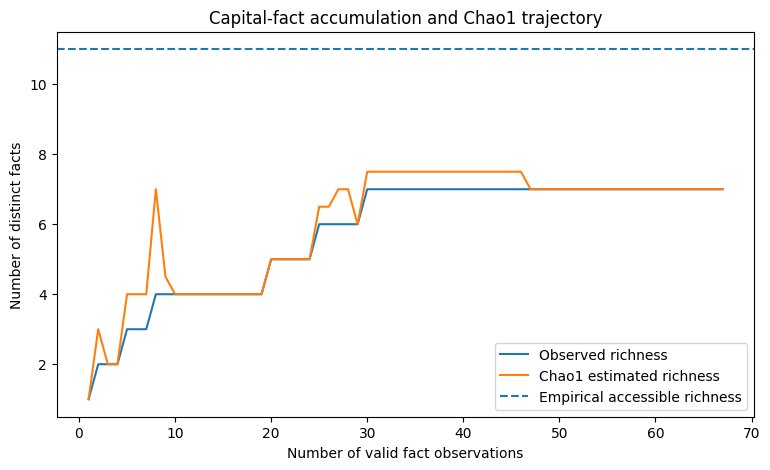

In [ ]:
trajectory = []
running_facts = []

for i, fact in enumerate(valid_facts, start=1):
    running_facts.append(fact)
    row = biodiversity_summary(running_facts)
    row["valid_observations"] = i
    trajectory.append(row)

trajectory_df = pd.DataFrame(trajectory)

plt.figure(figsize=(9, 5))
plt.plot(
    trajectory_df["valid_observations"],
    trajectory_df["S_obs"],
    label="Observed richness",
)
plt.plot(
    trajectory_df["valid_observations"],
    trajectory_df["Chao1"],
    label="Chao1 estimated richness",
)
plt.axhline(
    S_ACCESSIBLE,
    linestyle="--",
    label="Empirical accessible richness",
)
plt.xlabel("Number of valid fact observations")
plt.ylabel("Number of distinct facts")
plt.title("Capital-fact accumulation and Chao1 trajectory")
plt.legend()
plt.show()

In [ ]:
observed_set = set(fact_counts)

print("Accessible in direct probing but unseen in free sampling:")
for fact in sorted(ACCESSIBLE_FACTS - observed_set):
    print(" ", fact)

print("\nObserved in free sampling but not found in Phase A:")
for fact in sorted(observed_set - ACCESSIBLE_FACTS):
    print(" ", fact)

Accessible in direct probing but unseen in free sampling:
  ('Comoros', 'Moroni')
  ('Estonia', 'Tallinn')
  ('Micronesia', 'Palikir')
  ('Palau', 'Ngerulmud')
  ('Suriname', 'Paramaribo')

Observed in free sampling but not found in Phase A:
  ('Brazil', 'Brasilia')


# Detailed tutorial: estimating unseen country–capital knowledge in a small LLM

This notebook is written as a **step-by-step teaching notebook**.

We use a small frozen instruction model:

```text
Qwen/Qwen2.5-0.5B-Instruct
```

We do **not** train or fine-tune it.

The complete experiment answers this question:

> After observing only some country–capital facts generated by the model, can we estimate how many additional correct facts remain unseen?

---

## Main idea

We create a very small factual universe:

```text
country → capital
```

Then we do two different experiments.

### Phase A — Direct probing

We directly ask:

```text
What is the capital of Palau?
```

This approximates which facts are accessible when the model receives a strong cue.

### Phase B — Free-choice sampling

We ask:

```text
Choose one country from this list and state its capital.
```

The model chooses which fact to reveal.

Repeated calls create a frequency distribution:

```text
France–Paris       20 observations
Japan–Tokyo        14 observations
Palau–Ngerulmud     1 observation
```

We then calculate:

- observed richness;
- singleton facts;
- doubleton facts;
- Chao1 total-richness estimate;
- Chao1 unseen-richness estimate;
- Good–Turing probability of seeing a new fact next.

Every calculation is shown manually.

In [ ]:
import ast
import json
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print("Random seed:", SEED)
print("Selected model:", MODEL_ID)
print("Selected device:", device)
print("Selected numerical type:", dtype)

Random seed: 42
Selected model: Qwen/Qwen2.5-0.5B-Instruct
Selected device: cuda
Selected numerical type: torch.float16


# Define the small factual universe

We use only 12 country–capital facts.

The table has two purposes:

1. It tells us which answers are correct.
2. It defines a closed toy universe.

The table is **not** given to the model as training data.

In [ ]:
GROUND_TRUTH = {
    "France": "Paris",
    "Japan": "Tokyo",
    "Türkiye": "Ankara",
    "Brazil": "Brasilia",
    "Canada": "Ottawa",
    "Australia": "Canberra",
    "Estonia": "Tallinn",
    "Mongolia": "Ulaanbaatar",
    "Suriname": "Paramaribo",
    "Palau": "Ngerulmud",
    "Comoros": "Moroni",
    "Micronesia": "Palikir",
}

ALIASES = {
    "brasilia": "Brasilia",
    "brasília": "Brasilia",
    "turkey": "Türkiye",
    "turkiye": "Türkiye",
    "türkiye": "Türkiye",
    "federated states of micronesia": "Micronesia",
    "micronesia": "Micronesia",
}

universe_df = pd.DataFrame(
    [
        {
            "fact_id": i + 1,
            "country": country,
            "capital": capital,
            "canonical_fact": f"{country} → {capital}",
        }
        for i, (country, capital) in enumerate(GROUND_TRUTH.items())
    ]
)

print("Number of possible facts in the reference universe:", len(universe_df))
print("\nReference universe:")
display(universe_df)

Number of possible facts in the reference universe: 12

Reference universe:


,fact_id,country,capital,canonical_fact
0,1,France,Paris,France → Paris
1,2,Japan,Tokyo,Japan → Tokyo
2,3,Türkiye,Ankara,Türkiye → Ankara
3,4,Brazil,Brasilia,Brazil → Brasilia
4,5,Canada,Ottawa,Canada → Ottawa
5,6,Australia,Canberra,Australia → Canberra
6,7,Estonia,Tallinn,Estonia → Tallinn
7,8,Mongolia,Ulaanbaatar,Mongolia → Ulaanbaatar
8,9,Suriname,Paramaribo,Suriname → Paramaribo
9,10,Palau,Ngerulmud,Palau → Ngerulmud


# Load the frozen pretrained model

The model is loaded with pretrained weights.

The following line:

```python
model.eval()
```

places the model in evaluation mode.

The model is never updated because:

- we do not create an optimizer;
- we do not calculate gradients;
- we use `torch.inference_mode()`.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
).to(device)

model.eval()

print("Model loaded successfully.")
print("Training mode active?", model.training)
print("False means that the model is in evaluation mode.")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model loaded successfully.
Training mode active? False
False means that the model is in evaluation mode.


# Create one function for model inference

This function:

1. formats a chat prompt;
2. converts the prompt to tokens;
3. runs the frozen model;
4. decodes only newly generated tokens;
5. returns the generated text.

In [ ]:
def generate_one(
    prompt,
    *,
    do_sample=True,
    temperature=0.8,
    max_new_tokens=50,
):
    messages = [
        {
            "role": "system",
            "content": (
                "You are a factual assistant. "
                "Follow the requested output format exactly. "
                "Do not invent countries outside the supplied list."
            ),
        },
        {
            "role": "user",
            "content": prompt,
        },
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
    ).to(device)

    generation_arguments = {
        **model_inputs,
        "max_new_tokens": max_new_tokens,
        "do_sample": do_sample,
        "pad_token_id": tokenizer.eos_token_id,
    }

    if do_sample:
        generation_arguments["temperature"] = temperature
        generation_arguments["top_p"] = 0.95

    with torch.inference_mode():
        generated = model.generate(**generation_arguments)

    generated_only = generated[
        0,
        model_inputs["input_ids"].shape[1]:,
    ]

    answer = tokenizer.decode(
        generated_only,
        skip_special_tokens=True,
    ).strip()

    return answer


print("Generation function is ready.")

Generation function is ready.


# Test one model call manually

Before running many samples, inspect one answer.

The model is asked directly about France.

In [ ]:
test_prompt = """
What is the capital of France?

Return exactly:
{"country": "France", "capital": "CITY"}
"""

test_answer = generate_one(
    test_prompt,
    do_sample=False,
    max_new_tokens=30,
)

print("PROMPT")
print("------")
print(test_prompt)

print("\nRAW MODEL ANSWER")
print("----------------")
print(test_answer)

PROMPT
------

What is the capital of France?

Return exactly:
{"country": "France", "capital": "CITY"}


RAW MODEL ANSWER
----------------
The capital of France is Paris.


# Parse generated text into a country–capital pair

Models do not always return perfect JSON.

The parser tries:

1. JSON;
2. Python-dictionary syntax;
3. a fallback text pattern.

After parsing, a response becomes:

```python
("France", "Paris")
```

In [ ]:
def normalize_text(value):
    """Remove common formatting around generated values."""
    if value is None:
        return None

    value = str(value).strip()

    # Remove markdown/code formatting.
    value = value.replace("```json", "")
    value = value.replace("```python", "")
    value = value.replace("```", "")
    value = value.strip()

    # Remove surrounding quotes and punctuation.
    value = value.strip('"').strip("'")
    value = value.strip()
    value = value.rstrip(".,;:}")

    return value.strip()


def normalize_country(value):
    value = normalize_text(value)

    if value is None:
        return None

    return ALIASES.get(value.casefold(), value)


def normalize_capital(value):
    value = normalize_text(value)

    if value is None:
        return None

    return value


def parse_pair(text, expected_country=None):
    """
    Parse a country-capital pair from several possible model-output formats.

    expected_country:
        For a direct question such as "What is the capital of France?",
        pass expected_country="France". This allows parsing an answer that
        contains only the capital, such as "Paris".
    """
    if text is None:
        return None, None

    cleaned_text = str(text).strip()

    if not cleaned_text:
        return None, None

    # ---------------------------------------------------------
    # Attempt 1: Find and parse a JSON/Python dictionary.
    # Examples:
    # {"country": "France", "capital": "Paris"}
    # {'country': 'France', 'capital': 'Paris'}
    # ---------------------------------------------------------
    dictionary_matches = re.findall(
        r"\{[^{}]*\}",
        cleaned_text,
        flags=re.DOTALL,
    )

    for candidate in dictionary_matches:
        for parser in (json.loads, ast.literal_eval):
            try:
                parsed = parser(candidate)

                if not isinstance(parsed, dict):
                    continue

                # Accept different capitalization of dictionary keys.
                normalized_keys = {
                    str(key).strip().casefold(): value
                    for key, value in parsed.items()
                }

                country = normalized_keys.get("country")
                capital = normalized_keys.get("capital")

                if country is not None and capital is not None:
                    return (
                        normalize_country(country),
                        normalize_capital(capital),
                    )

            except (json.JSONDecodeError, ValueError, SyntaxError, TypeError):
                continue

    # ---------------------------------------------------------
    # Attempt 2: Match labeled text.
    # Examples:
    # Country: France, Capital: Paris
    # country = France
    # capital = Paris
    # ---------------------------------------------------------
    labeled_match = re.search(
        r"\bcountry\b\s*[:=\-]\s*"
        r'["\']?([^,"\';\n}]+)["\']?'
        r".*?"
        r"\bcapital\b\s*[:=\-]\s*"
        r'["\']?([^,"\';\n}]+)["\']?',
        cleaned_text,
        flags=re.IGNORECASE | re.DOTALL,
    )

    if labeled_match:
        return (
            normalize_country(labeled_match.group(1)),
            normalize_capital(labeled_match.group(2)),
        )

    # ---------------------------------------------------------
    # Attempt 3: Match a natural-language sentence.
    # Examples:
    # The capital of France is Paris.
    # France's capital is Paris.
    # ---------------------------------------------------------
    natural_patterns = [
        (
            r"\bthe\s+capital\s+of\s+(.+?)\s+is\s+"
            r"([A-Za-zÀ-ÿ .'\-]+?)(?:[.!?\n]|$)"
        ),
        (
            r"\b(.+?)(?:'s|’s)\s+capital\s+is\s+"
            r"([A-Za-zÀ-ÿ .'\-]+?)(?:[.!?\n]|$)"
        ),
        (
            r"\bcapital\s+city\s+of\s+(.+?)\s+is\s+"
            r"([A-Za-zÀ-ÿ .'\-]+?)(?:[.!?\n]|$)"
        ),
    ]

    for pattern in natural_patterns:
        natural_match = re.search(
            pattern,
            cleaned_text,
            flags=re.IGNORECASE,
        )

        if natural_match:
            return (
                normalize_country(natural_match.group(1)),
                normalize_capital(natural_match.group(2)),
            )

    # ---------------------------------------------------------
    # Attempt 4: Direct-question fallback.
    #
    # If the question already identifies the country, the model
    # may return only:
    # Paris
    #
    # In that situation, use expected_country.
    # ---------------------------------------------------------
    if expected_country is not None:
        candidate_capital = cleaned_text

        # Remove common prefixes.
        candidate_capital = re.sub(
            r"^(the\s+capital\s+is|capital\s*[:=\-])\s*",
            "",
            candidate_capital,
            flags=re.IGNORECASE,
        )

        # Remove markdown fences.
        candidate_capital = candidate_capital.replace("```json", "")
        candidate_capital = candidate_capital.replace("```", "")
        candidate_capital = normalize_capital(candidate_capital)

        # Accept only a reasonably short answer as a capital.
        if (
            candidate_capital
            and "\n" not in candidate_capital
            and len(candidate_capital.split()) <= 6
        ):
            return (
                normalize_country(expected_country),
                candidate_capital,
            )

    return None, None

In [ ]:
print("RAW ANSWER:")
print(repr(test_answer))

parsed_country, parsed_capital = parse_pair(
    test_answer,
    expected_country="France",
)

print("Parsed country:", parsed_country)
print("Parsed capital:", parsed_capital)

RAW ANSWER:
'The capital of France is Paris.'
Parsed country: France
Parsed capital: Paris


# Check whether a parsed answer is correct

A generated pair is valid when:

1. the country belongs to our 12-country universe;
2. the generated capital equals the reference capital.

Example:

```text
France → Paris
```

is valid.

Example:

```text
France → Lyon
```

is invalid.

In [ ]:
def evaluate_pair(country, capital):
    if country not in GROUND_TRUTH:
        return False

    if capital is None:
        return False

    gold_capital = GROUND_TRUTH[country]

    return capital.casefold() == gold_capital.casefold()


test_is_correct = evaluate_pair(
    parsed_country,
    parsed_capital,
)

print("Generated pair:", (parsed_country, parsed_capital))
print("Expected capital:", GROUND_TRUTH.get(parsed_country))
print("Is the answer correct?", test_is_correct)

Generated pair: ('France', 'Paris')
Expected capital: Paris
Is the answer correct? True


# Phase A — Direct probing of every country

We now ask directly about all 12 countries.

For every country:

- use 3 prompt templates;
- repeat each template 3 times.

Therefore, the total number of direct-probing calls is:

\[
12 \times 3 \times 3 = 108.
\]

A fact is called **empirically accessible** if the correct answer appears at least once among its 9 attempts.

In [ ]:
DIRECT_TEMPLATES = [
    (
        'What is the capital of {country}? '
        'Return JSON: {{"country": "{country}", "capital": "CITY"}}'
    ),
    (
        'Complete this fact: the capital city of {country} is what? '
        'Return JSON only with keys country and capital.'
    ),
    (
        'Name the current capital of {country}. '
        'Output exactly one JSON object with country and capital.'
    ),
]

DIRECT_REPEATS = 3

expected_direct_calls = (
    len(GROUND_TRUTH)
    * len(DIRECT_TEMPLATES)
    * DIRECT_REPEATS
)

print("Countries:", len(GROUND_TRUTH))
print("Templates per country:", len(DIRECT_TEMPLATES))
print("Repeats per template:", DIRECT_REPEATS)
print("Expected direct-probing calls:", expected_direct_calls)

Countries: 12
Templates per country: 3
Repeats per template: 3
Expected direct-probing calls: 108


## Run direct probing

This cell prints progress country by country.

In [ ]:
direct_rows = []

for country_index, (country, gold_capital) in enumerate(
    GROUND_TRUTH.items(),
    start=1,
):
    print(
        f"Probing country {country_index}/{len(GROUND_TRUTH)}: "
        f"{country}"
    )

    for template_id, template in enumerate(DIRECT_TEMPLATES):
        for repeat in range(DIRECT_REPEATS):
            prompt = template.format(country=country)

            raw_answer = generate_one(
                prompt,
                do_sample=True,
                temperature=0.5,
                max_new_tokens=40,
            )

            parsed_country, parsed_capital = parse_pair(raw_answer)

            # Because this is a direct query, the intended country is known.
            is_correct = (
                parsed_capital is not None
                and parsed_capital.casefold()
                == gold_capital.casefold()
            )

            direct_rows.append(
                {
                    "country": country,
                    "gold_capital": gold_capital,
                    "template_id": template_id,
                    "repeat": repeat,
                    "raw_output": raw_answer,
                    "parsed_country": parsed_country,
                    "parsed_capital": parsed_capital,
                    "is_correct": is_correct,
                }
            )

direct_df = pd.DataFrame(direct_rows)

print("\nDirect probing finished.")
print("Actual number of rows:", len(direct_df))

Probing country 1/12: France
Probing country 2/12: Japan
Probing country 3/12: Türkiye
Probing country 4/12: Brazil
Probing country 5/12: Canada
Probing country 6/12: Australia
Probing country 7/12: Estonia
Probing country 8/12: Mongolia
Probing country 9/12: Suriname
Probing country 10/12: Palau
Probing country 11/12: Comoros
Probing country 12/12: Micronesia

Direct probing finished.
Actual number of rows: 108


## Inspect the direct-probing responses

Look at the raw text and the parsed result.

In [ ]:
display_columns = [
    "country",
    "gold_capital",
    "template_id",
    "repeat",
    "raw_output",
    "parsed_capital",
    "is_correct",
]

print("First 20 direct-probing attempts:")
display(direct_df[display_columns].head(20))

First 20 direct-probing attempts:


,country,gold_capital,template_id,repeat,raw_output,parsed_capital,is_correct
0,France,Paris,0,0,"{""country"": ""France"", ""capital"": ""Paris""}",Paris,True
1,France,Paris,0,1,"{""country"": ""France"", ""capital"": ""Paris""}",Paris,True
2,France,Paris,0,2,"{""country"": ""France"", ""capital"": ""Paris""}",Paris,True
3,France,Paris,1,0,"{\n ""country"": ""France"",\n ""capital"": ""Paris...",Paris,True
4,France,Paris,1,1,"```json\n{\n ""country"": ""France"",\n ""capital...",Paris,True
5,France,Paris,1,2,"```json\n{\n ""country"": ""France"",\n ""capital...",Paris,True
6,France,Paris,2,0,"{\n ""country"": ""France"",\n ""capital"": ""Paris...",Paris,True
7,France,Paris,2,1,"{\n ""country"": ""France"",\n ""capital"": ""Paris...",Paris,True
8,France,Paris,2,2,"{\n ""country"": ""France"",\n ""capital"": ""Paris...",Paris,True
9,Japan,Tokyo,0,0,"{""country"": ""Japan"", ""capital"": ""Tokyo""}",Tokyo,True


## Calculate fact-level accessibility

For each country, calculate:

$
\text{detection rate}
=
\frac{\text{correct attempts}}
{\text{total attempts}}
$

A fact is marked accessible when:

$
\text{correct attempts} > 0.
$

In [ ]:
accessibility = (
    direct_df
    .groupby(
        ["country", "gold_capital"],
        as_index=False,
    )
    .agg(
        correct_attempts=("is_correct", "sum"),
        total_attempts=("is_correct", "size"),
    )
)

accessibility["detection_rate"] = (
    accessibility["correct_attempts"]
    / accessibility["total_attempts"]
)

accessibility["accessible"] = (
    accessibility["correct_attempts"] > 0
)

ACCESSIBLE_FACTS = {
    (row.country, row.gold_capital)
    for row in accessibility.itertuples()
    if row.accessible
}

S_ACCESSIBLE = len(ACCESSIBLE_FACTS)

print("Accessibility results:")
display(
    accessibility.sort_values(
        ["accessible", "detection_rate"],
        ascending=[False, False],
    )
)

print("\nREFERENCE UNIVERSE SIZE")
print("-----------------------")
print(len(GROUND_TRUTH))

print("\nEMPIRICALLY ACCESSIBLE RICHNESS")
print("--------------------------------")
print(S_ACCESSIBLE)

print(
    "\nInterpretation: the model produced the correct answer "
    "at least once for this many country–capital facts."
)

Accessibility results:


,country,gold_capital,correct_attempts,total_attempts,detection_rate,accessible
0,Australia,Canberra,9,9,1.000000,True
2,Canada,Ottawa,9,9,1.000000,True
5,France,Paris,9,9,1.000000,True
6,Japan,Tokyo,9,9,1.000000,True
4,Estonia,Tallinn,8,9,0.888889,True
8,Mongolia,Ulaanbaatar,7,9,0.777778,True
3,Comoros,Moroni,4,9,0.444444,True
7,Micronesia,Palikir,4,9,0.444444,True
11,Türkiye,Ankara,4,9,0.444444,True
10,Suriname,Paramaribo,3,9,0.333333,True



REFERENCE UNIVERSE SIZE
-----------------------
12

EMPIRICALLY ACCESSIBLE RICHNESS
--------------------------------
11

Interpretation: the model produced the correct answer at least once for this many country–capital facts.


# Phase B — Free-choice biodiversity sampling

Now we stop asking about each country directly.

Instead, every call gives the model the entire list and asks it to choose one country.

The model may prefer familiar countries.

Example frequency distribution:

```text
France–Paris       20
Japan–Tokyo        15
Palau–Ngerulmud     1
```

This is the abundance data used by Chao1 and Good–Turing.

In [ ]:
ALLOWED_COUNTRIES = list(GROUND_TRUTH)

FREE_PROMPT = f"""
Choose exactly one country from this allowed list:

{", ".join(ALLOWED_COUNTRIES)}

State its correct capital.

Try to vary your choice across independent calls.

Return exactly one JSON object:
{{"country": "COUNTRY", "capital": "CITY"}}
"""

print(FREE_PROMPT)


Choose exactly one country from this allowed list:

France, Japan, Türkiye, Brazil, Canada, Australia, Estonia, Mongolia, Suriname, Palau, Comoros, Micronesia

State its correct capital.

Try to vary your choice across independent calls.

Return exactly one JSON object:
{"country": "COUNTRY", "capital": "CITY"}



## Run repeated free-choice inference

For a first CPU test, use:

```python
N_SAMPLES = 30
```

For a better GPU experiment, use:

```python
N_SAMPLES = 120
```

Each model call is one sampling unit.

In [ ]:
N_SAMPLES = 60

print("Number of planned sampling units:", N_SAMPLES)
print("One model call = one sampling unit.")

Number of planned sampling units: 60
One model call = one sampling unit.


In [ ]:
sample_rows = []

for sample_id in range(N_SAMPLES):
    raw_answer = generate_one(
        FREE_PROMPT,
        do_sample=True,
        temperature=1.1,
        max_new_tokens=45,
    )

    country, capital = parse_pair(raw_answer)

    is_valid_fact = evaluate_pair(
        country,
        capital,
    )

    if is_valid_fact:
        canonical_fact = (
            country,
            GROUND_TRUTH[country],
        )
    else:
        canonical_fact = None

    sample_rows.append(
        {
            "sample_id": sample_id + 1,
            "raw_output": raw_answer,
            "country": country,
            "capital": capital,
            "is_valid_fact": is_valid_fact,
            "canonical_fact": canonical_fact,
        }
    )

    if (sample_id + 1) % 10 == 0:
        print(
            f"Completed {sample_id + 1}/{N_SAMPLES} "
            "free-choice samples."
        )

samples_df = pd.DataFrame(sample_rows)

print("\nFree-choice sampling finished.")

Completed 10/60 free-choice samples.
Completed 20/60 free-choice samples.
Completed 30/60 free-choice samples.
Completed 40/60 free-choice samples.
Completed 50/60 free-choice samples.
Completed 60/60 free-choice samples.

Free-choice sampling finished.


## Inspect every free-choice answer

This table shows:

- raw response;
- parsed pair;
- whether it is valid;
- canonical species identifier.

In [ ]:
display(samples_df)

,sample_id,raw_output,country,capital,is_valid_fact,canonical_fact
0,1,"```json\n{\n ""country"": ""Australia"",\n ""capi...",Australia,Perth,False,None
1,2,"{\n ""country"": ""Canada"",\n ""capital"": ""Ottaw...",Canada,Ottawa,True,"(Canada, Ottawa)"
2,3,"{""country"": ""Türkiye"", ""capital"": ""İstanbul""}",Türkiye,İstanbul,False,None
3,4,"Here's the chosen country and capital, varying...",Tonga,Pele,False,None
4,5,"```json\n{\n ""country"": ""Japan"",\n ""capital""...",Japan,Tokyo,True,"(Japan, Tokyo)"
5,6,"```json\n{\n ""country"": ""Taiwan"",\n ""capital...",Taiwan,Taipei,False,None
6,7,"{\n ""country"": ""Australia"",\n ""capital"": ""Pe...",Australia,Perth,False,None
7,8,"```json\n{\n ""country"": ""India"",\n ""capital""...",India,Delhi,False,None
8,9,"{""country"": ""Japan"", ""capital"": ""Tokyo""}",Japan,Tokyo,True,"(Japan, Tokyo)"
9,10,"{\n ""country"": ""Brazil"",\n ""capital"": ""Búwai...",Brazil,Búwaitim,False,None
